In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from som_model import GeneralCLASSOM

In [2]:
import pandas as pd
import pathlib as path 

df = pd.read_csv("../data/features_SOM_train_fulltest_200HZ.csv")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDescribe:")
print(df.describe())

Shape: (95728, 6)

Columns:
Index(['HR', 'HRV_RMSSD', 'HRV_SDNN', 'SCR_Count', 'EDA_Tonic_log',
       'EDA_Phasic_log'],
      dtype='str')

Describe:
                 HR     HRV_RMSSD      HRV_SDNN     SCR_Count  EDA_Tonic_log  \
count  95728.000000  95728.000000  95728.000000  95728.000000   95728.000000   
mean      80.066585     69.944343     63.603372      0.804028       6.939971   
std       11.237376     45.891563     33.244119      1.118906       0.609628   
min       52.596467      6.871843      6.519202      0.000000      -5.000000   
25%       71.935414     35.753174     40.107337      0.000000       6.661570   
50%       79.246085     55.226805     55.970741      0.000000       6.756803   
75%       87.490935     92.509149     77.960749      1.000000       6.901693   
max      141.215822    200.000000    200.000000     12.000000      10.000000   

       EDA_Phasic_log  
count    95728.000000  
mean        -2.111259  
std          1.656869  
min         -5.000000  
25%    

In [3]:
def topographic_error(som, data):

    error_count = 0

    for x in data:

        # avstånd till alla neuroner
        weights = som.get_weights()
        dists = np.linalg.norm(weights - x, axis=2)

        # hitta BMU och second BMU
        bmu_idx = np.unravel_index(np.argmin(dists), dists.shape)

        dists[bmu_idx] = np.inf
        second_bmu = np.unravel_index(np.argmin(dists), dists.shape)

        # kontrollera om de är grannar
        if max(abs(bmu_idx[0]-second_bmu[0]),
               abs(bmu_idx[1]-second_bmu[1])) > 1:
            error_count += 1

    return error_count / len(data)

In [4]:
data_path = Path("../data/features_SOM_train_fulltest_200HZ.csv")

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (95728, 6)


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
0,78.296149,147.723197,123.306545,0,6.910931,1.564513
1,78.507671,146.123521,122.515091,0,6.926156,0.260854
2,78.783175,142.265504,121.117575,0,6.941121,0.615907
3,79.586022,140.541535,119.988715,0,6.955828,0.417669
4,80.586136,138.620435,107.562517,0,6.970273,0.488999


In [5]:
X_200 = df.values

print(X_200.shape)

(95728, 6)


In [15]:
som_clas_200 = GeneralCLASSOM(

    x=20,
    y=20,
    input_len=6,

    sigma=12,
    learning_rate=0.3,

    random_seed=42
)

som_clas_200.get_summary()

{'x': 20,
 'y': 20,
 'input_len': 6,
 'sigma': 12,
 'learning_rate': 0.3,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

In [16]:
som_clas_200.train(

    X_200,

    iterations=300000,
    mode="batch",

    use_pca=True,
    verbose=True
)

 [ 300000 / 300000 ] 100% - 0:00:00 left 
 quantization error: 2.115474601306423
Training completed (300000 iterations)


In [17]:
scaled_train = som_clas_200.scaler.transform(X_200)

qe = som_clas_200.som.quantization_error(scaled_train)

te = topographic_error(
    som_clas_200.som,
    scaled_train
)

print("Quantization Error:", qe)
print("Topographic Error:", te)

Quantization Error: 2.115474601306423
Topographic Error: 0.029594267090088583


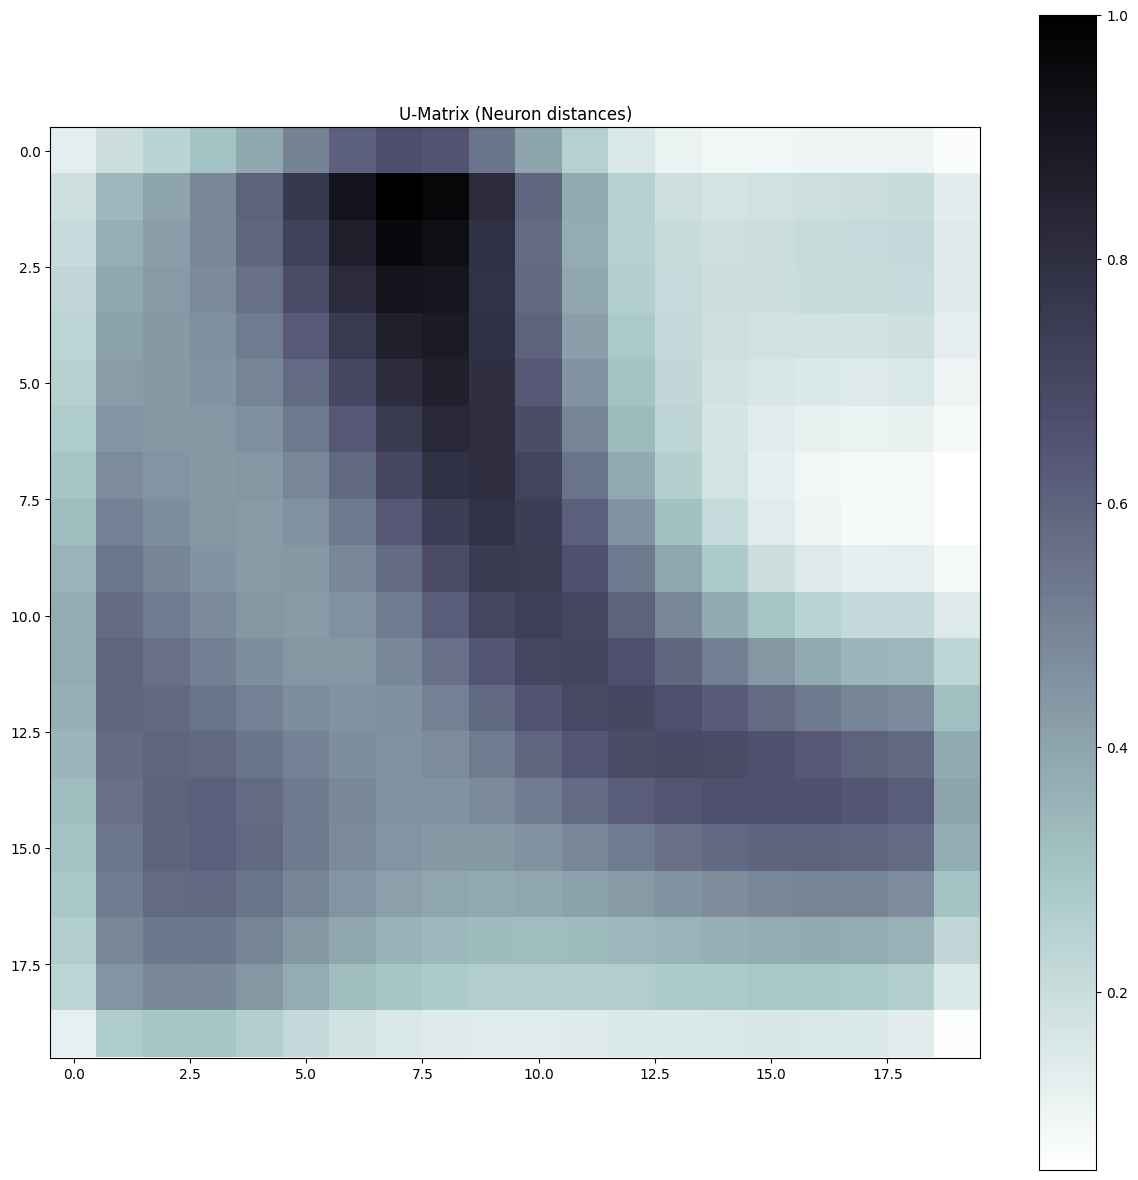

In [18]:
u_matrix = som_clas_200.get_u_matrix()

plt.figure(figsize=(15,15))
plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()
plt.title("U-Matrix (Neuron distances)")
plt.show()

In [19]:
cluster_map = som_clas_200.create_clusters(
    data=X_200,
    n_clusters=3,
    method="density"
)

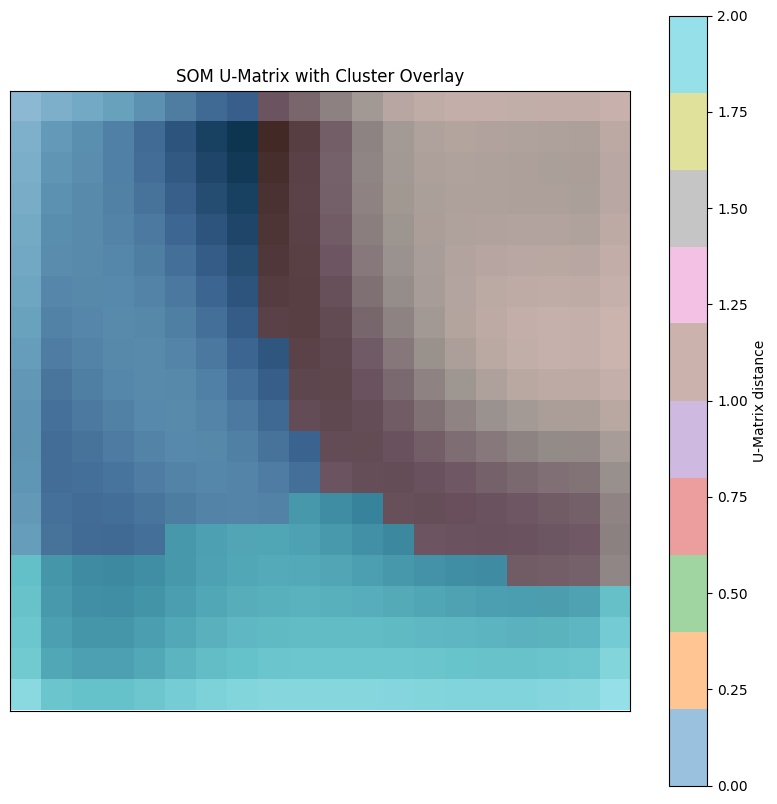

In [20]:
plt.figure(figsize=(10,10))

plt.imshow(u_matrix, cmap="bone_r")

plt.imshow(
    cluster_map,
    cmap="tab10",
    alpha=0.45
)

plt.colorbar(label="U-Matrix distance")

plt.title("SOM U-Matrix with Cluster Overlay")

plt.xticks([])
plt.yticks([])

plt.show()

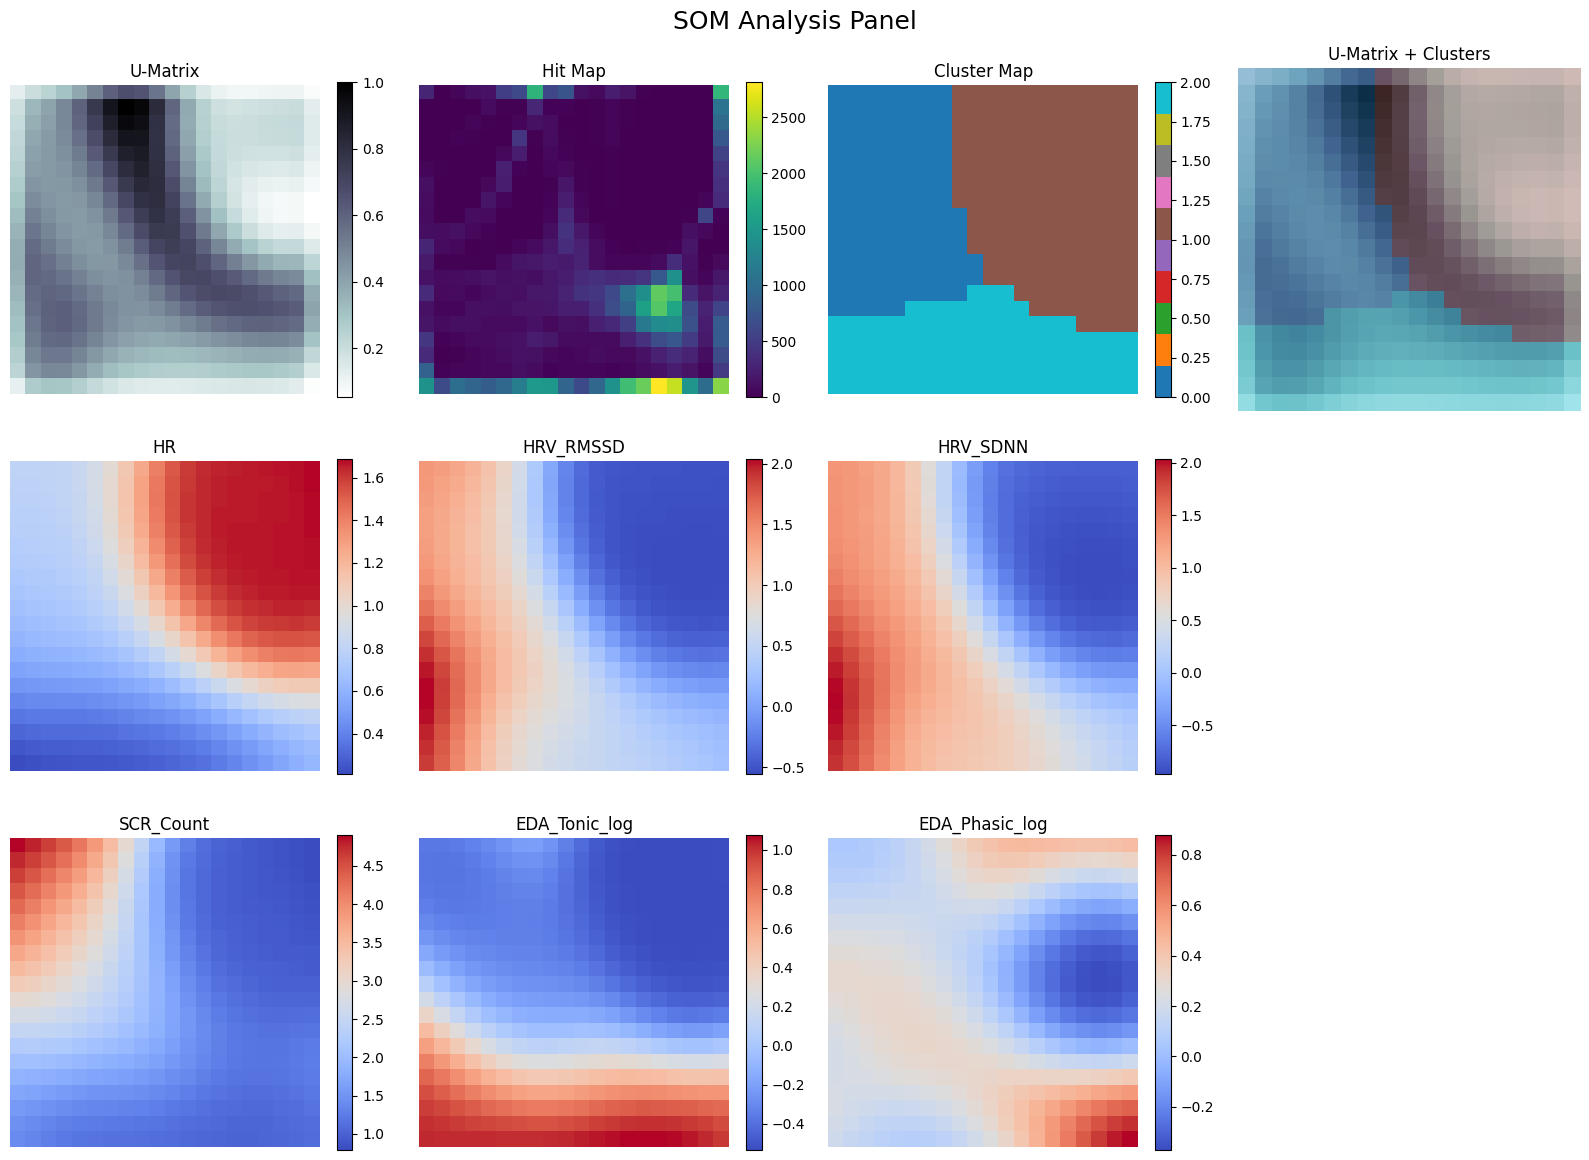

In [21]:
# ===== COMPLETE SOM VISUALIZATION PANEL =====

import matplotlib.pyplot as plt
import numpy as np

# ---- Prepare data ----
scaled_data = som_clas_200.scaler.transform(X_200)

u_matrix = som_clas_200.get_u_matrix()

hits = som_clas_200.som.activation_response(scaled_data)

cluster_map = som_clas_200.create_clusters(
    data=X_200,
    n_clusters=3,
    method="density"
)

weights = som_clas_200.som.get_weights()

feature_names = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

# ---- Figure layout ----
fig = plt.figure(figsize=(16,12))

grid = fig.add_gridspec(3,4)

# ---- U-Matrix ----
ax1 = fig.add_subplot(grid[0,0])
im = ax1.imshow(u_matrix, cmap="bone_r")
ax1.set_title("U-Matrix")
ax1.axis("off")
plt.colorbar(im, ax=ax1, fraction=0.046)

# ---- Hit Map ----
ax2 = fig.add_subplot(grid[0,1])
im = ax2.imshow(hits, cmap="viridis")
ax2.set_title("Hit Map")
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)

# ---- Cluster Map ----
ax3 = fig.add_subplot(grid[0,2])
im = ax3.imshow(cluster_map, cmap="tab10")
ax3.set_title("Cluster Map")
ax3.axis("off")
plt.colorbar(im, ax=ax3, fraction=0.046)

# ---- U-Matrix + Cluster Overlay ----
ax4 = fig.add_subplot(grid[0,3])
ax4.imshow(u_matrix, cmap="bone_r")
ax4.imshow(cluster_map, cmap="tab10", alpha=0.4)
ax4.set_title("U-Matrix + Clusters")
ax4.axis("off")

# ---- Feature Maps ----
for i in range(6):

    row = 1 + i // 3
    col = i % 3

    ax = fig.add_subplot(grid[row, col])

    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.046)

# ---- Layout ----
plt.suptitle("SOM Analysis Panel", fontsize=18)
plt.tight_layout()
plt.show()

In [22]:
df["cluster"] = som_clas_200.predict_cluster(X_200)

cluster_profiles = df.groupby("cluster").mean()

cluster_profiles

,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
cluster,,,,,,
0,82.061728,105.063671,89.378313,2.936848,6.708440,-2.396409
1,86.199272,40.364260,42.349996,0.602228,6.720162,-2.632500
2,74.778779,84.250094,73.746531,0.427744,7.169550,-1.632900


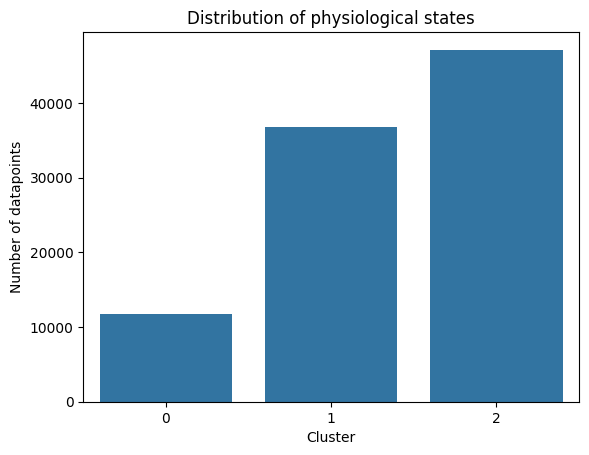

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="cluster", data=df)

plt.title("Distribution of physiological states")
plt.xlabel("Cluster")
plt.ylabel("Number of datapoints")

plt.show()

In [24]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "stress_som_model_200_HZ_20x20.pkl"

som_clas_200.save_model(model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\stress_som_model_200_HZ_20x20.pkl
